In [4]:
%pip install networkx pygraphviz neo4j langchain-experimental --q
# install the required libaries
! pip install google-generativeai --quiet
! pip install pypdf --quiet # required for LangChain pdf reader
#! pip install tiktoken --quiet # required for splitting document by number of tokens
! pip install sentence_transformers --quiet # for creating embeddings

Note: you may need to restart the kernel to use updated packages.


### Loading the ISLR book using PDF loader

In [6]:
from langchain.document_loaders import PyPDFLoader

ISLR_Book = '/kaggle/input/ml-ops-as/An Introduction To Statistical Learning with Applications in R (ISLR Sixth Printing).pdf'

pdf_loader = PyPDFLoader(file_path=ISLR_Book)
ISLR_Book = pdf_loader.load_and_split()

In [7]:
len(ISLR_Book)

444

In [8]:
ISLR_Book[:5]

[Document(page_content='Springer Texts in Statistics\nSeries Editors:\nG. Casella\nS. Fienberg\nI. Olkin\nFor further volumes:\nhttp://www.springer.com/series/417', metadata={'source': '/kaggle/input/ml-ops-as/An Introduction To Statistical Learning with Applications in R (ISLR Sixth Printing).pdf', 'page': 0}),
 Document(page_content='Gareth James •Daniela Witten •Trevor Hastie\nRobert Tibshirani\nAn Introduction to\nStatistical Learning\nwith Applications in R\n123', metadata={'source': '/kaggle/input/ml-ops-as/An Introduction To Statistical Learning with Applications in R (ISLR Sixth Printing).pdf', 'page': 2}),
 Document(page_content='Gareth James\nDepartment of Information and\nOperations Management\nUniversity of Southern California\nLos Angeles, CA, USA\nTrevor Hastie\nDepartment of Statistics\nStanford University\nStanford, CA, USADaniela Witten\nDepartment of Biostatistics\nUniversity of Washington\nSeattle, WA, USA\nRobert Tibshirani\nDepartment of Statistics\nStanford Univer

In [9]:
ISLR_Book[0].page_content

'Springer Texts in Statistics\nSeries Editors:\nG. Casella\nS. Fienberg\nI. Olkin\nFor further volumes:\nhttp://www.springer.com/series/417'

### LLM using Google Palm2

In [12]:
from langchain.llms import GooglePalm

llm = GooglePalm(google_api_key='YOUR PALM2 Key',
                 temperature=0.5,
                top_k=1)

### Graph and GraphIndex Creation

In [13]:
from langchain.indexes import GraphIndexCreator

index_creator = GraphIndexCreator(llm=llm)

graph = index_creator.from_text(ISLR_Book[17].page_content)

### Triples - relationship in graphs

In [14]:
graph.get_triples()

[('1908', 'LEAST SQUARES', 'EARLIEST FORM OF'),
 ('LINEAR REGRESSION', 'PREDICTING QUANTITATIVE VALUES', 'USED FOR'),
 ('LINEAR REGRESSION',
  'PROBLEMS IN ASTRONOMY',
  'FIRST SUCCESSFULLY APPLIED TO'),
 ('1936', 'LINEAR DISCRIMINANT ANALYSIS', 'PROPOSED'),
 ('1970s', 'GENERALIZED LINEAR MODELS', 'COINED THE TERM'),
 ('GENERALIZED LINEAR MODELS',
  'BOTH LINEAR AND LOGISTIC REGRESSION AS SPECIAL CASES',
  'INCLUDE'),
 ('1980s', 'FINALLY IMPROVED SUFFICIENTLY', 'COMPUTED TECHNOLOGY'),
 ('1980s', 'NO LONGER COMPUTATIONAL PROHIBITIVE', 'NON-LINEAR METHODS'),
 ('1980s', 'CLASSIFICATION AND REGRESSION TREES', 'INTRODUCED'),
 ('1986', 'GENERALIZED ADDITIVE MODELS', 'COINED THE TERM'),
 ('1986', 'PRACTICAL SOFTWARE IMPLEMENTATION', 'PROVIDED'),
 ('STATISTICAL LEARNING',
  'SUPERVISED AND UNSUPERVISED MODELING AND PREDICTION',
  'FOCUSED ON'),
 ('RECENT YEARS',
  'MARKED BY THE INCREASING AVAILABILITY OF POWERFUL AND RELATIVELY USER-FRIENDLY SOFTWARE',
  'PROGRESS IN STATISTICAL LEARNING'),
 

### Visualizing a sample graph

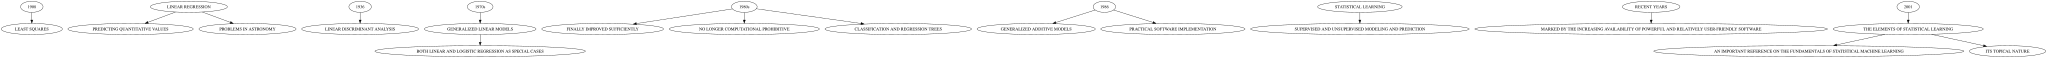

In [15]:
from IPython.display import SVG
graph.draw_graphviz(path="book.svg")
SVG('book.svg')

### Creating graph for set of Page Contents

In [16]:
graphs = [
    index_creator.from_text(doc.page_content) 
    for doc in ISLR_Book[10:30]
]

### compose(G, H) in networkx
Compose graph G with H by combining nodes and edges into a single graph.

Returns
A new graph with the same type as G

In [17]:
import networkx as nx

graph_nx = graphs[0]._graph
for g in graphs[1:]:
    graph_nx = nx.compose(graph_nx, g._graph)

In [18]:
from langchain.graphs.networkx_graph import NetworkxEntityGraph

graph = NetworkxEntityGraph(graph_nx)
graph

In [19]:
graph.draw_graphviz(path="ISLR_Book.pdf", prog='fdp')

In [20]:
from IPython.display import SVG
graph.draw_graphviz(path="ISLR_Book.svg")
SVG('ISLR_Book.svg')

### GraphQAChain

In [24]:
from langchain.chains import GraphQAChain


chain = GraphQAChain.from_llm(
    llm=llm, 
    graph=graph, 
    verbose=True
)

question = """
Which chapter has the details about Linear Regression?
"""

chain.run(question)



> Entering new GraphQAChain chain...
Entities Extracted:
Linear Regression
Full Context:


> Finished chain.


'Chapter 2'

In [25]:
question = """
What is written in chapter 2 about linear regression?
"""

chain.run(question)



> Entering new GraphQAChain chain...
Entities Extracted:
2
Full Context:


> Finished chain.


'Linear regression is a statistical method'

In [26]:
question = """
What is MSE and which chapter has details about MSE?
"""

chain.run(question)



> Entering new GraphQAChain chain...
Entities Extracted:
MSE
Full Context:


> Finished chain.


'Mean squared error    Chapter 10'

In [27]:
question = """
What we can learn from ISLR?
"""

chain.run(question)



> Entering new GraphQAChain chain...
Entities Extracted:
ISLR
Full Context:
ISLR AUTHOR Gareth James
ISLR AUTHOR Daniela Witten
ISLR AUTHOR Trevor Hastie
ISLR AUTHOR Robert Tibshirani
ISLR YEAR 2013
ISLR PUBLISHER Springer
ISLR KEYWORDS Statistical Learning
ISLR KEYWORDS Data Mining
ISLR KEYWORDS Machine Learning
ISLR KEYWORDS Regression
ISLR KEYWORDS Classification
ISLR KEYWORDS Clustering
ISLR KEYWORDS Dimensionality Reduction
ISLR KEYWORDS Anomaly Detection
ISLR KEYWORDS Natural Language Processing
ISLR KEYWORDS Recommender Systems
ISLR KEYWORDS Computer Vision
ISLR KEYWORDS Bioinformatics
ISLR KEYWORDS Time Series
ISLR KEYWORDS Survival Analysis
ISLR KEYWORDS High-Dimensional Data
ISLR KEYWORDS Big Data
ISLR KEYWORDS Software
ISLR KEYWORDS Applications
ISLR KEYWORDS Theory
ISLR KEYWORDS Mathematics
ISLR KEYWORDS R
ISLR KEYWORDS Python
ISLR KEYWORDS MATLAB
ISLR KEYWORDS SAS
ISLR KEYWORDS Weka
ISLR KEYWORDS SVM
ISLR KEYWORDS Neural Networks
ISLR KEYWORDS Boosting
ISLR KEYWORDS Rand

'Statistical Learning, Data Mining, Machine Learning, Regression, Classification, Clustering, Dimensionality Reduction, Anomaly Detection, Natural Language Processing, Recommender Systems, Computer Vision, Bioinformatics, Time Series, Survival Analysis, High-Dimensional Data, Big Data, Software, Applications, Theory, Mathematics, R, Python, MATLAB, SAS, Weka, SVM, Neural Networks, Boosting, Random Forests, Support Vector Machines, Boosting'

In [28]:
question = """
What is Random Forest?
"""

chain.run(question)



> Entering new GraphQAChain chain...
Entities Extracted:
Random Forest
Full Context:


> Finished chain.


'ensemble learning'